# Dataset Reformulation for Learning-to-Rank

**Goal:** Transform feature-engineered datasets into a learning-to-rank format where:
- Each row = (Task_ID, Employee_ID) pair
- Each Task_ID forms a group (the model ranks employees within each group)
- Relevance label = 1 if the employee worked on the task, 0 otherwise
- Employee features come from a train-only historical profile (no leakage)
- Negative employees are sampled per task (smart negative sampling)
- Class imbalance is handled via ranking objectives + sample weights, NOT via SMOTE/oversampling

## Step 1: Load and Validate

In [25]:
import pandas as pd
import numpy as np
import json
import os
import joblib
from sklearn.preprocessing import LabelEncoder

train_df = pd.read_csv("../data/processed/split_datasets/feature_engineered_train_dataset.csv")
val_df = pd.read_csv("../data/processed/split_datasets/feature_engineered_val_dataset.csv")
test_df = pd.read_csv("../data/processed/split_datasets/feature_engineered_test_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

assert set(train_df["Task_ID"]).isdisjoint(set(val_df["Task_ID"]))
assert set(train_df["Task_ID"]).isdisjoint(set(test_df["Task_ID"]))
assert set(val_df["Task_ID"]).isdisjoint(set(test_df["Task_ID"]))

print("Task_ID leakage check passed: all splits are disjoint")

Train shape: (8314, 38)
Val shape:   (1588, 38)
Test shape:  (1728, 38)
Task_ID leakage check passed: all splits are disjoint


## Step 2: Drop Leakage Columns

In [26]:
LEAKAGE_COLS = [
    "Hours_Spent",
    "FLAG_LEAKAGE_Actual_Hours_Spent",
    "FLAG_LEAKAGE_Timesheet_Work_Logs",
    "FLAG_LEAKAGE_Timesheet_Logs_Count",
    "FLAG_LEAKAGE_Task_Stage",
    "FLAG_LEAKAGE_All_Collaborating_Employees",
    "Debug_Skill_Scores",
    "Task_Skills",
]

for df in [train_df, val_df, test_df]:
    dropped = [c for c in LEAKAGE_COLS if c in df.columns]
    df.drop(columns=dropped, inplace=True)

print(f"Train columns after leakage drop: {train_df.shape[1]}")
print(f"Val columns after leakage drop:   {val_df.shape[1]}")
print(f"Test columns after leakage drop:  {test_df.shape[1]}")

Train columns after leakage drop: 30
Val columns after leakage drop:   30
Test columns after leakage drop:  30


## Step 3: Aggregate Duplicate Rows to (Task_ID, Employee_ID)

In [27]:
NUMERIC_AGG = {
    "Estimated_Planned_Hours": "mean",
    "Planned_Hours_Log": "mean",
    "Task_Text_Length": "mean",
    "Task_Word_Count": "mean",
    "Task_Description_Length": "mean",
    "Task_Name_Length": "mean",
    "Has_Task_Description": "max",
    "Has_Deadline": "max",
    "Days_To_Deadline": "mean",
    "Task_Skill_Count": "mean",
    "Project_Task_Count_Train": "first",
    "Project_Avg_Skill_Count_Train": "first",
    "Project_Avg_Planned_Hours_Train": "first",
    "Created_Year": "first",
    "Created_Month": "first",
    "Created_DayOfWeek": "first",
    "Created_Quarter": "first",
}

CATEGORICAL_COLS = ["Task_Priority", "Employee_Department", "Employee_Job_Position"]

def aggregate_to_task_employee(df, name):
    agg_dict = {**NUMERIC_AGG}
    for c in CATEGORICAL_COLS:
        if c in df.columns:
            agg_dict[c] = "first"
    string_cols = [
        "Task_Name", "Task_Text", "Date", "Task_Description",
        "Project_Name", "Created_Date", "Deadline_Date", "Planned_Task_Size"
    ]
    for c in string_cols:
        if c in df.columns:
            agg_dict[c] = "first"
    valid_agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}
    out = df.groupby(["Task_ID", "Employee_ID"], as_index=False).agg(valid_agg_dict)
    print(f"{name}: {df.shape} -> {out.shape}")
    return out

train_agg = aggregate_to_task_employee(train_df, "train")
val_agg = aggregate_to_task_employee(val_df, "val")
test_agg = aggregate_to_task_employee(test_df, "test")

train: (8314, 30) -> (2425, 30)
val: (1588, 30) -> (509, 30)
test: (1728, 30) -> (487, 30)


---
## EDA: Per-Employee Task Analysis

Exploratory analysis of each Employee ID and their task distribution across the training dataset.

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

emp_task_counts = (
    train_agg.groupby("Employee_ID")["Task_ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Task_ID": "Task_Count"})
)

print("=== Employee Task Count Summary ===")
print(f"Total employees:          {emp_task_counts.shape[0]}")
print(f"Total unique tasks:       {train_agg['Task_ID'].nunique()}")
print(f"Max tasks (1 employee):   {emp_task_counts['Task_Count'].max()}")
print(f"Min tasks (1 employee):   {emp_task_counts['Task_Count'].min()}")
print(f"Mean tasks per employee:  {emp_task_counts['Task_Count'].mean():.1f}")
print(f"Median tasks per employee:{emp_task_counts['Task_Count'].median():.1f}")
display(emp_task_counts)

=== Employee Task Count Summary ===
Total employees:          49
Total unique tasks:       1709
Max tasks (1 employee):   178
Min tasks (1 employee):   1
Mean tasks per employee:  49.5
Median tasks per employee:31.0


,Employee_ID,Task_Count
0,EMP-11,178
1,EMP-16,161
2,EMP-5,151
3,EMP-8,128
4,EMP-7,124
5,EMP-10,112
6,EMP-41,106
7,EMP-21,103
8,EMP-22,102
9,EMP-4,94


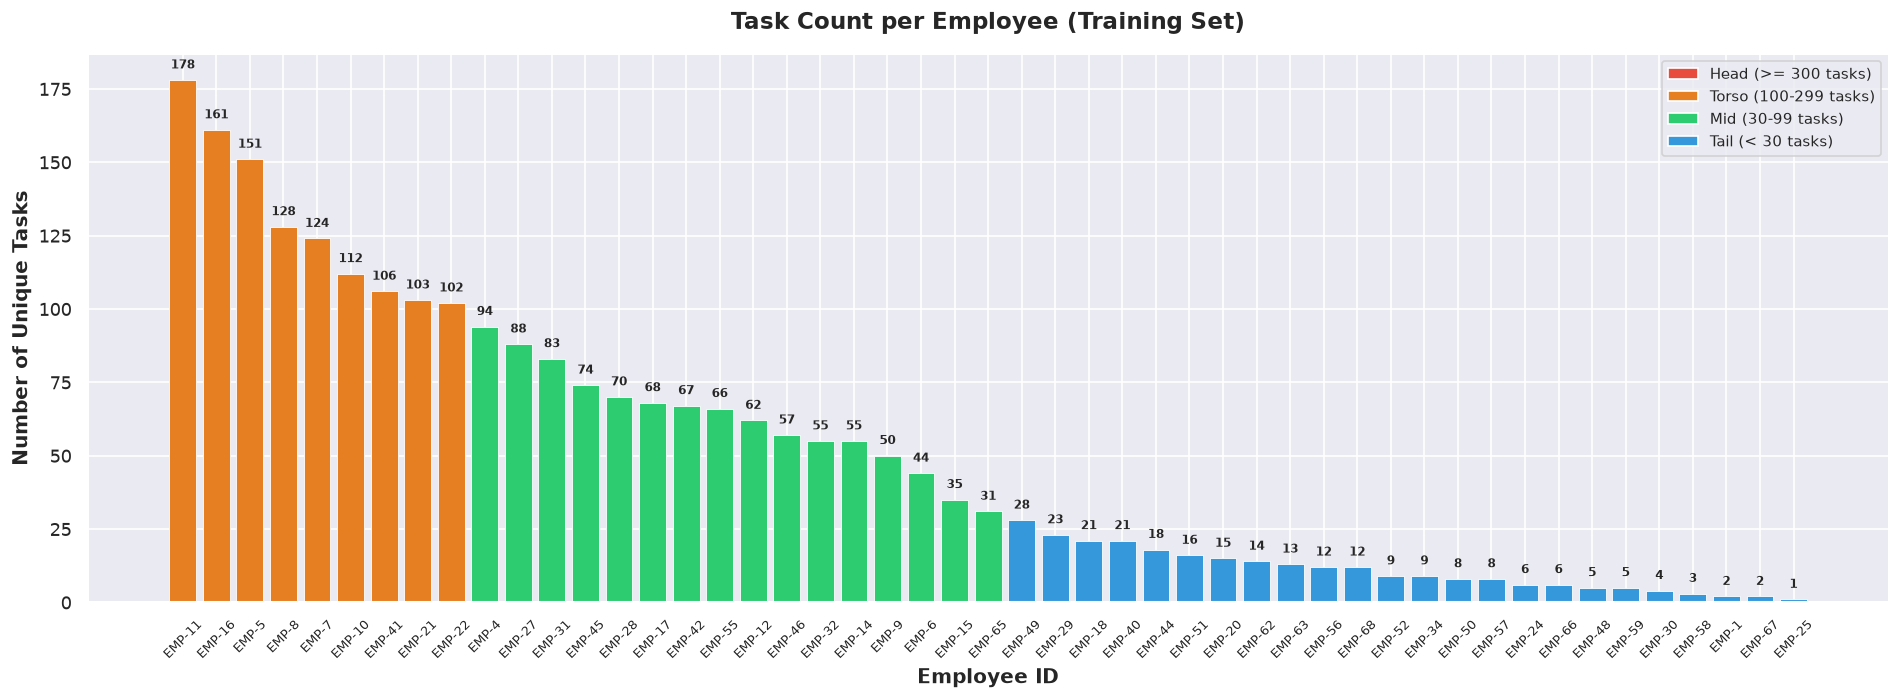

In [29]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = [
    "#e74c3c" if v >= 300 else
    "#e67e22" if v >= 100 else
    "#2ecc71" if v >= 30 else
    "#3498db"
    for v in emp_task_counts["Task_Count"]
]

bars = ax.bar(
    emp_task_counts["Employee_ID"].astype(str),
    emp_task_counts["Task_Count"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

for bar, val in zip(bars, emp_task_counts["Task_Count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(val),
        ha="center", va="bottom",
        fontsize=7, fontweight="bold"
    )

ax.set_xlabel("Employee ID", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Unique Tasks", fontsize=12, fontweight="bold")
ax.set_title("Task Count per Employee (Training Set)", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Head (>= 300 tasks)"),
    Patch(facecolor="#e67e22", label="Torso (100-299 tasks)"),
    Patch(facecolor="#2ecc71", label="Mid (30-99 tasks)"),
    Patch(facecolor="#3498db", label="Tail (< 30 tasks)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

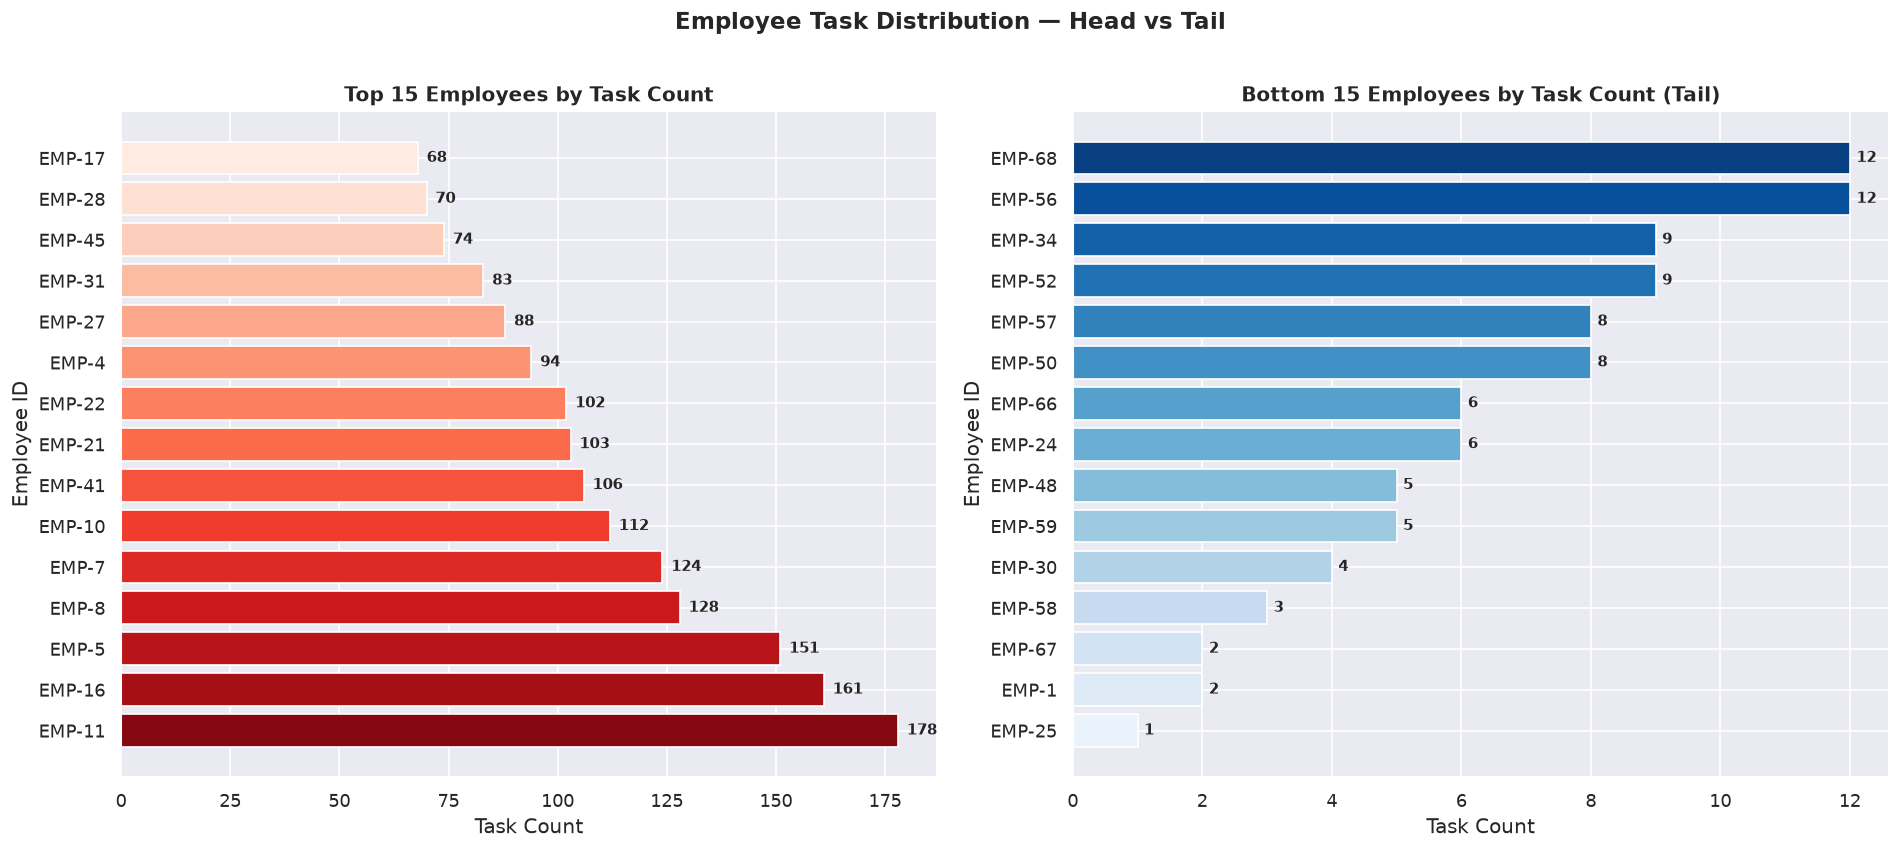

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_n = 15
top_emps = emp_task_counts.head(top_n)
bot_emps = emp_task_counts.tail(top_n).sort_values("Task_Count")

axes[0].barh(
    top_emps["Employee_ID"].astype(str),
    top_emps["Task_Count"],
    color=sns.color_palette("Reds_r", top_n)
)
for i, (val, emp) in enumerate(zip(top_emps["Task_Count"], top_emps["Employee_ID"])):
    axes[0].text(val + 2, i, str(val), va="center", fontsize=9, fontweight="bold")
axes[0].set_title(f"Top {top_n} Employees by Task Count", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Task Count")
axes[0].set_ylabel("Employee ID")

axes[1].barh(
    bot_emps["Employee_ID"].astype(str),
    bot_emps["Task_Count"],
    color=sns.color_palette("Blues", top_n)
)
for i, (val, emp) in enumerate(zip(bot_emps["Task_Count"], bot_emps["Employee_ID"])):
    axes[1].text(val + 0.1, i, str(val), va="center", fontsize=9, fontweight="bold")
axes[1].set_title(f"Bottom {top_n} Employees by Task Count (Tail)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Task Count")
axes[1].set_ylabel("Employee ID")

plt.suptitle("Employee Task Distribution — Head vs Tail", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

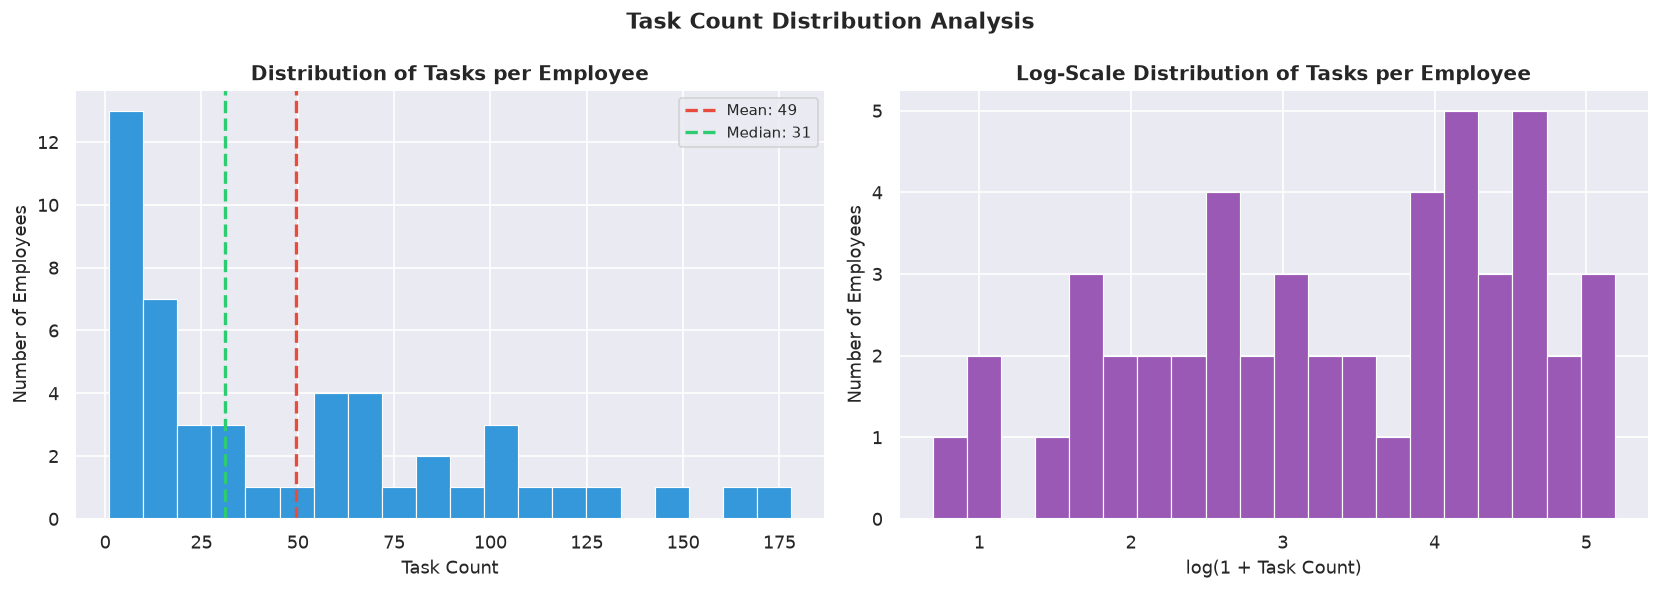

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    emp_task_counts["Task_Count"],
    bins=20, color="#3498db", edgecolor="white", linewidth=0.7
)
axes[0].axvline(emp_task_counts["Task_Count"].mean(), color="#e74c3c", linestyle="--", linewidth=2, label=f'Mean: {emp_task_counts["Task_Count"].mean():.0f}')
axes[0].axvline(emp_task_counts["Task_Count"].median(), color="#2ecc71", linestyle="--", linewidth=2, label=f'Median: {emp_task_counts["Task_Count"].median():.0f}')
axes[0].set_xlabel("Task Count", fontsize=11)
axes[0].set_ylabel("Number of Employees", fontsize=11)
axes[0].set_title("Distribution of Tasks per Employee", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

import numpy as np
axes[1].hist(
    np.log1p(emp_task_counts["Task_Count"]),
    bins=20, color="#9b59b6", edgecolor="white", linewidth=0.7
)
axes[1].set_xlabel("log(1 + Task Count)", fontsize=11)
axes[1].set_ylabel("Number of Employees", fontsize=11)
axes[1].set_title("Log-Scale Distribution of Tasks per Employee", fontsize=12, fontweight="bold")

plt.suptitle("Task Count Distribution Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

,Tier,Employee_Count,Total_Tasks,Task_Share_%
0,Torso (100-299),9,1165,48.0
1,Mid (30-99),16,999,41.2
2,Low (10-29),11,193,8.0
3,Tail (< 10),13,68,2.8


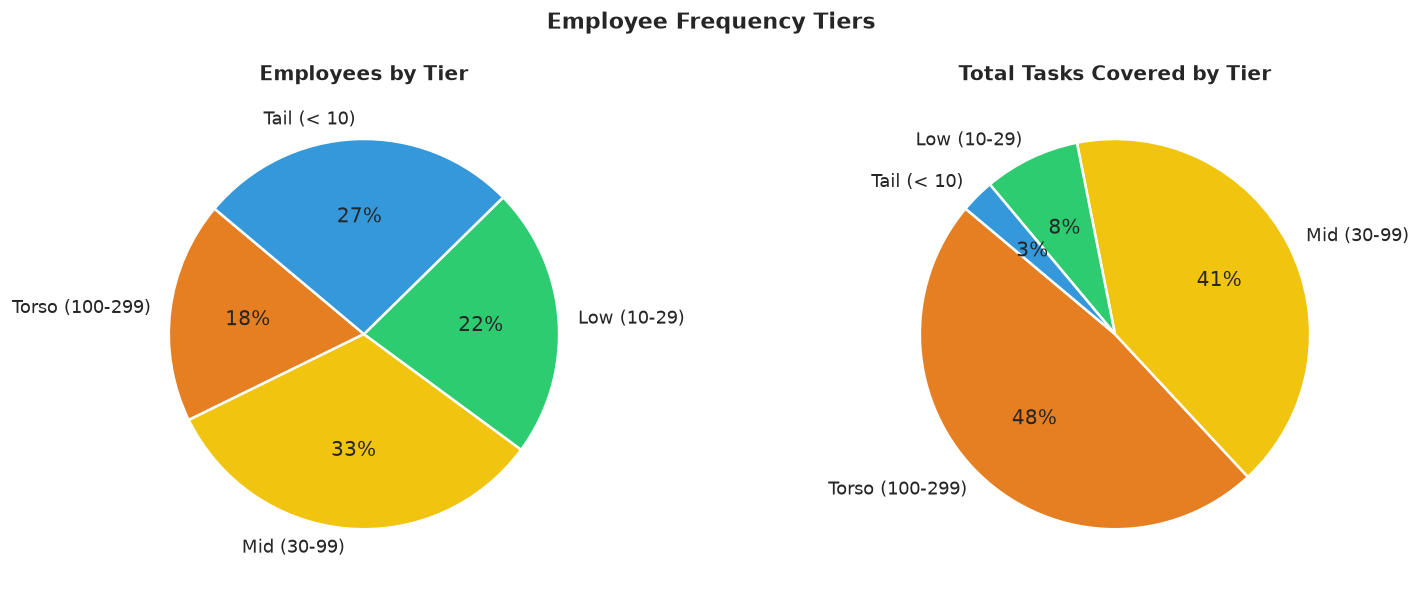

In [32]:
def assign_tier(count):
    if count >= 300:
        return "Head (>= 300)"
    elif count >= 100:
        return "Torso (100-299)"
    elif count >= 30:
        return "Mid (30-99)"
    elif count >= 10:
        return "Low (10-29)"
    else:
        return "Tail (< 10)"

emp_task_counts["Tier"] = emp_task_counts["Task_Count"].apply(assign_tier)

tier_order = ["Head (>= 300)", "Torso (100-299)", "Mid (30-99)", "Low (10-29)", "Tail (< 10)"]
tier_colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]

tier_summary = (
    emp_task_counts.groupby("Tier")
    .agg(Employee_Count=("Employee_ID", "count"), Total_Tasks=("Task_Count", "sum"))
    .reindex([t for t in tier_order if t in emp_task_counts["Tier"].unique()])
    .reset_index()
)
tier_summary["Task_Share_%"] = (tier_summary["Total_Tasks"] / tier_summary["Total_Tasks"].sum() * 100).round(1)
display(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

valid_tiers = tier_summary["Tier"].tolist()
palette = [tier_colors[tier_order.index(t)] for t in valid_tiers]

axes[0].pie(
    tier_summary["Employee_Count"],
    labels=valid_tiers,
    autopct="%1.0f%%",
    colors=palette,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[0].set_title("Employees by Tier", fontsize=12, fontweight="bold")

axes[1].pie(
    tier_summary["Total_Tasks"],
    labels=valid_tiers,
    autopct="%1.0f%%",
    colors=palette,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[1].set_title("Total Tasks Covered by Tier", fontsize=12, fontweight="bold")

plt.suptitle("Employee Frequency Tiers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

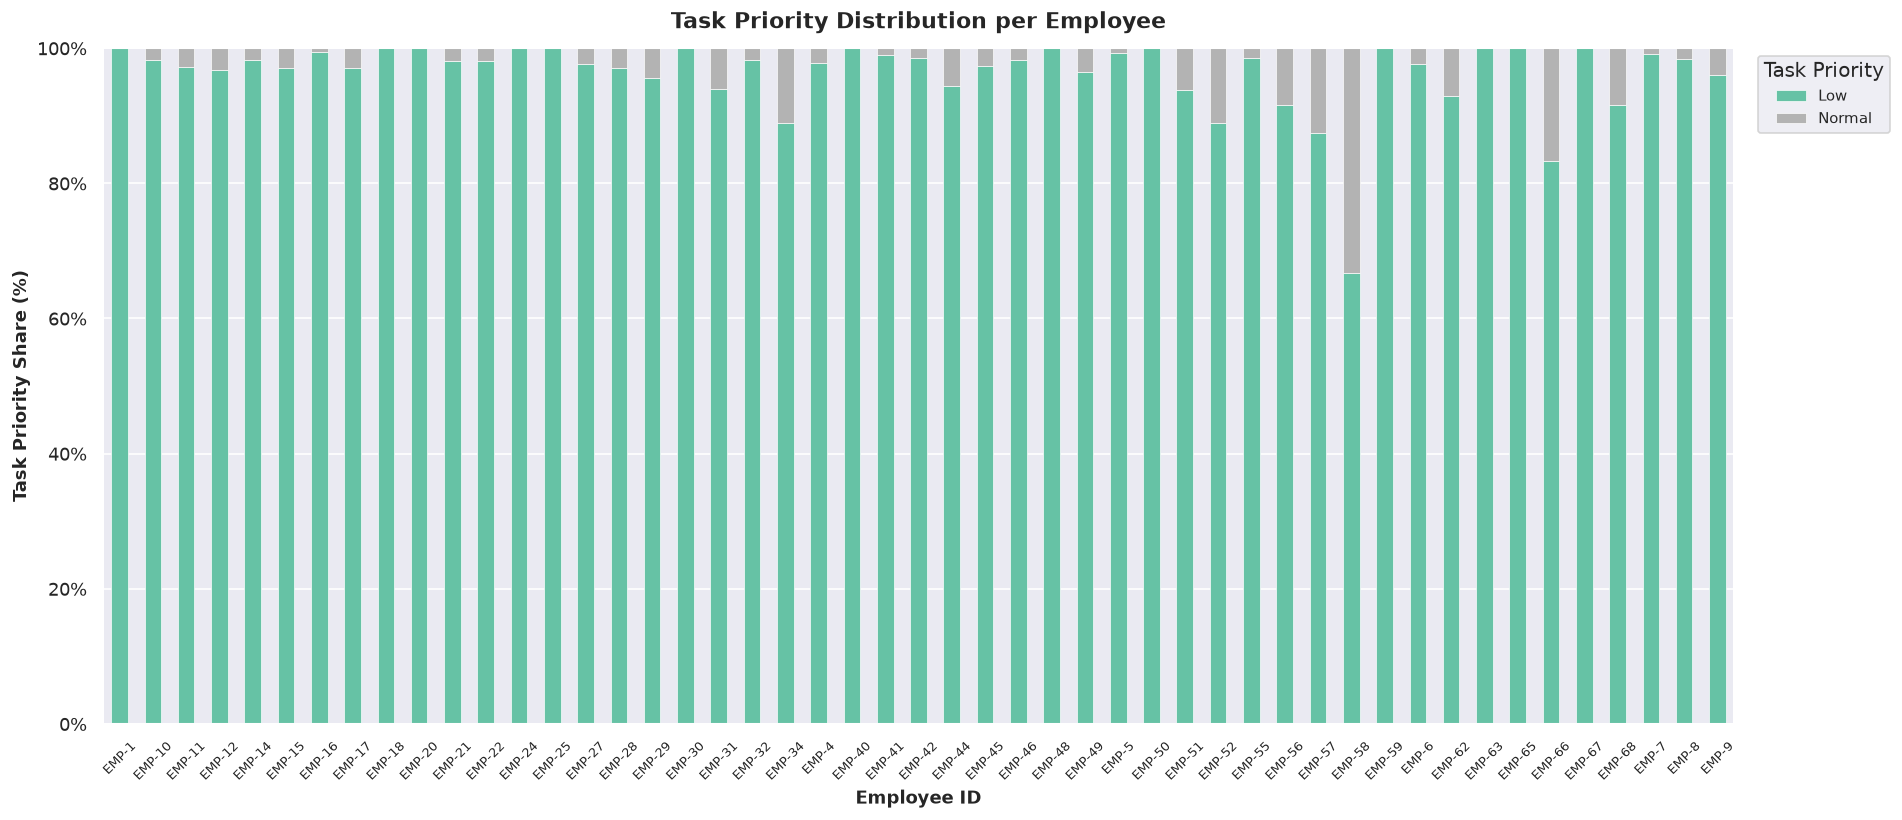

In [33]:
if "Task_Priority" in train_agg.columns:
    priority_matrix = (
        train_agg.groupby(["Employee_ID", "Task_Priority"])
        .size()
        .unstack(fill_value=0)
    )
    priority_pct = priority_matrix.div(priority_matrix.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(16, 7))
    priority_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        colormap="Set2",
        edgecolor="white",
        linewidth=0.4
    )
    ax.set_xlabel("Employee ID", fontsize=11, fontweight="bold")
    ax.set_ylabel("Task Priority Share (%)", fontsize=11, fontweight="bold")
    ax.set_title("Task Priority Distribution per Employee", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(title="Task Priority", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print("Task_Priority column not found in train_agg")

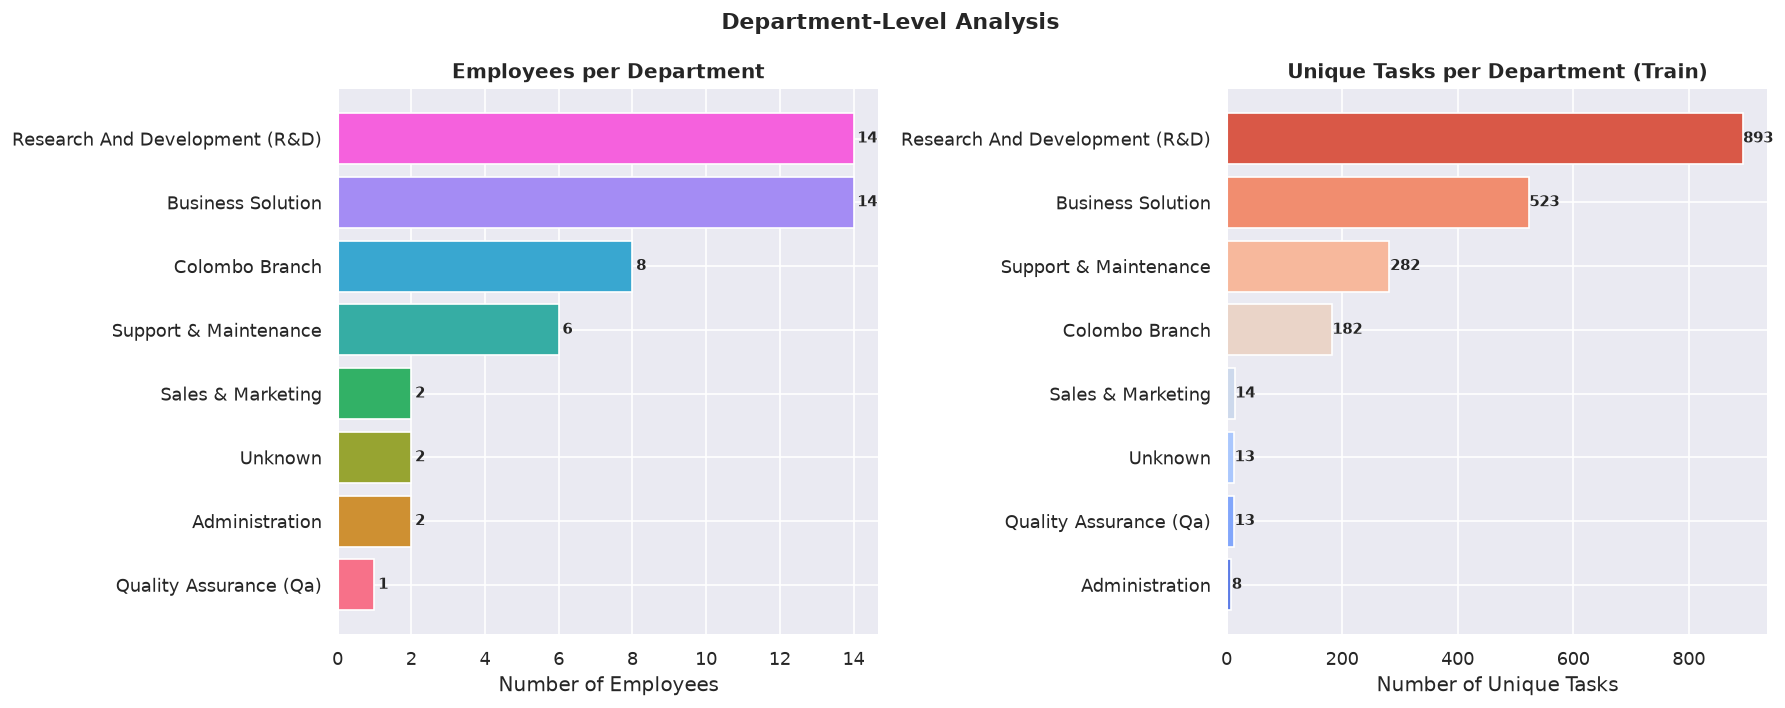

In [34]:
if "Employee_Department" in train_agg.columns:
    dept_counts = (
        train_agg[["Employee_ID", "Employee_Department"]]
        .drop_duplicates()
        .groupby("Employee_Department")["Employee_ID"]
        .count()
        .sort_values(ascending=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    colors_dept = sns.color_palette("husl", len(dept_counts))
    axes[0].barh(
        dept_counts.index.astype(str),
        dept_counts.values,
        color=colors_dept,
        edgecolor="white"
    )
    for i, v in enumerate(dept_counts.values):
        axes[0].text(v + 0.1, i, str(v), va="center", fontsize=9, fontweight="bold")
    axes[0].set_title("Employees per Department", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Number of Employees")

    dept_task = (
        train_agg.groupby("Employee_Department")["Task_ID"]
        .nunique()
        .sort_values(ascending=True)
    )
    axes[1].barh(
        dept_task.index.astype(str),
        dept_task.values,
        color=sns.color_palette("coolwarm", len(dept_task)),
        edgecolor="white"
    )
    for i, v in enumerate(dept_task.values):
        axes[1].text(v + 1, i, str(v), va="center", fontsize=9, fontweight="bold")
    axes[1].set_title("Unique Tasks per Department (Train)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Number of Unique Tasks")

    plt.suptitle("Department-Level Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Employee_Department column not found")

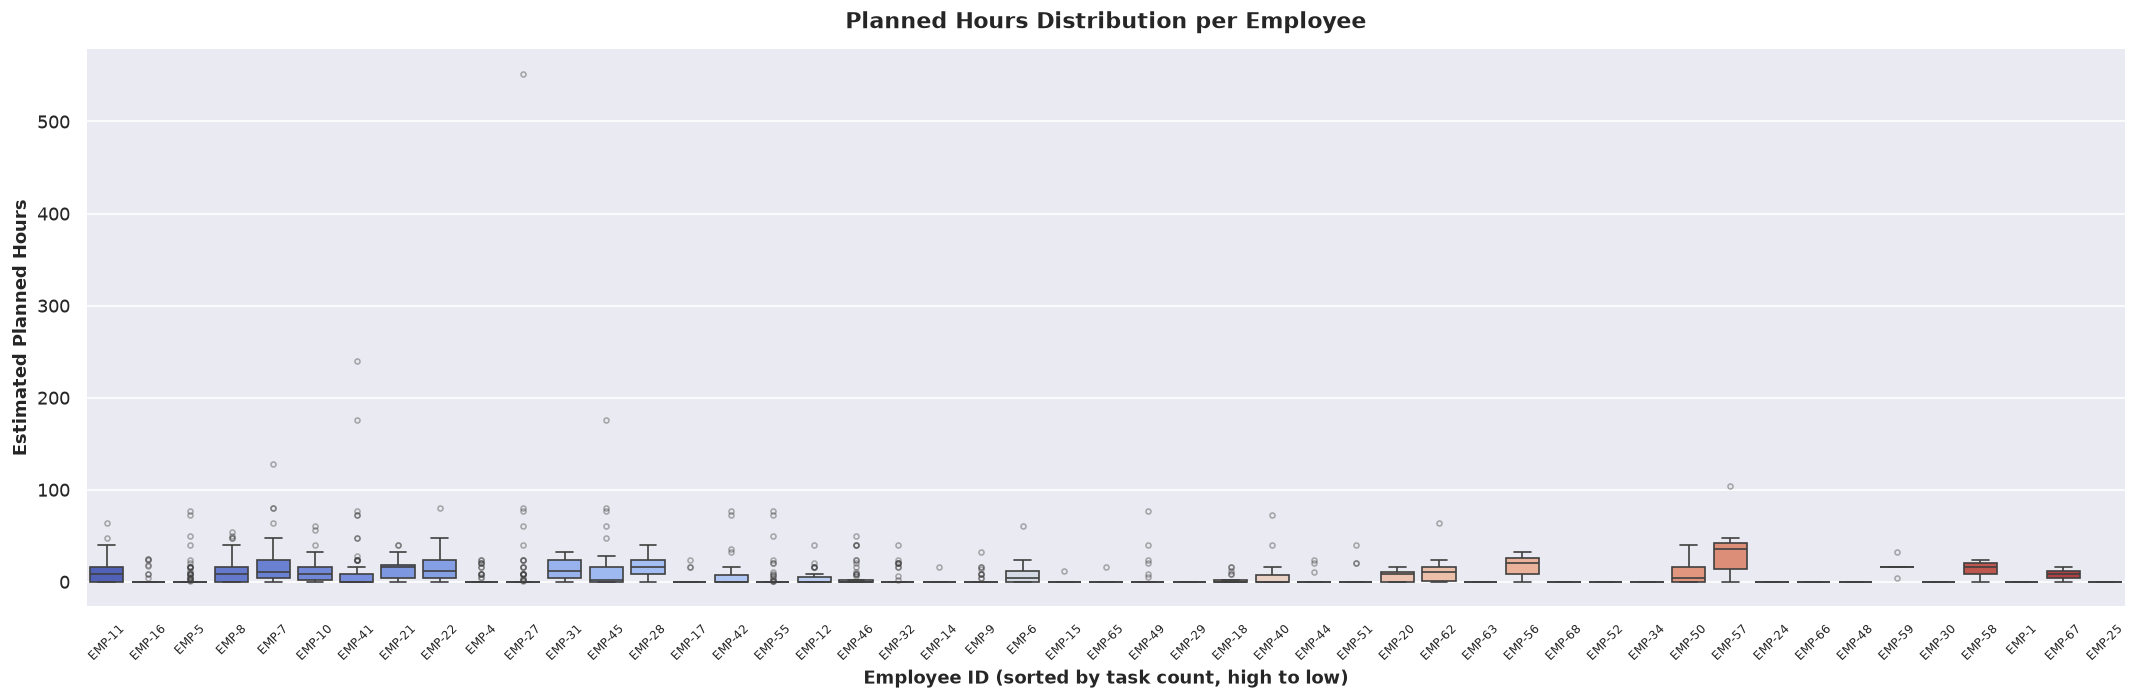

In [35]:
if "Estimated_Planned_Hours" in train_agg.columns:
    emp_order = emp_task_counts.sort_values("Task_Count", ascending=False)["Employee_ID"].astype(str).tolist()

    plot_data = train_agg.copy()
    plot_data["Employee_ID"] = plot_data["Employee_ID"].astype(str)

    fig, ax = plt.subplots(figsize=(18, 6))
    sns.boxplot(
        data=plot_data,
        x="Employee_ID",
        y="Estimated_Planned_Hours",
        order=emp_order,
        palette="coolwarm",
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        ax=ax
    )
    ax.set_xlabel("Employee ID (sorted by task count, high to low)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Estimated Planned Hours", fontsize=11, fontweight="bold")
    ax.set_title("Planned Hours Distribution per Employee", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("Estimated_Planned_Hours column not found")

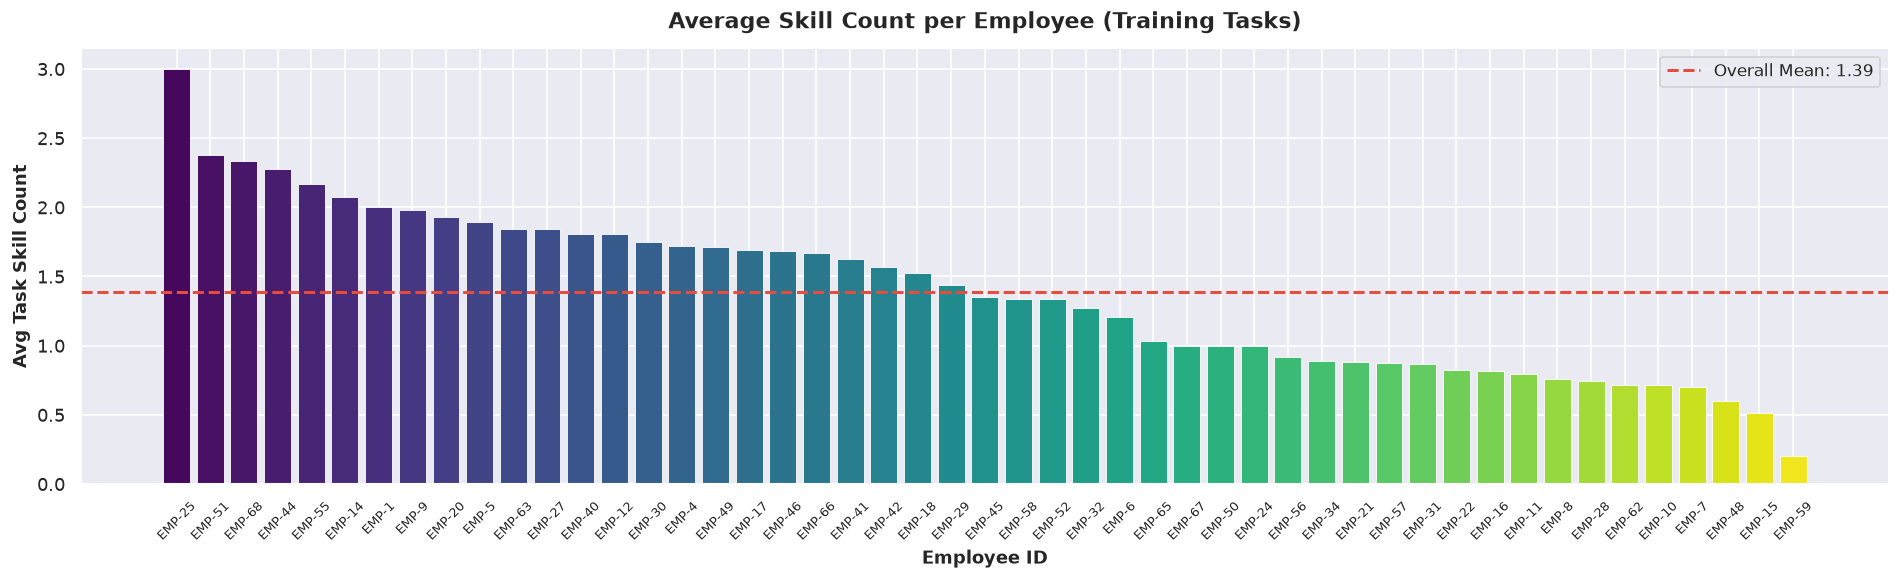

Top 5 Employees by Avg Skill Count:


,Employee_ID,Avg_Skill_Count
0,EMP-25,3.000000
1,EMP-51,2.375000
2,EMP-68,2.333333
3,EMP-44,2.277778
4,EMP-55,2.166667


Bottom 5 Employees by Avg Skill Count:


,Employee_ID,Avg_Skill_Count
44,EMP-10,0.714286
45,EMP-7,0.701613
46,EMP-48,0.600000
47,EMP-15,0.514286
48,EMP-59,0.200000


In [36]:
if "Task_Skill_Count" in train_agg.columns:
    skill_per_emp = (
        train_agg.groupby("Employee_ID")["Task_Skill_Count"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"Task_Skill_Count": "Avg_Skill_Count"})
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    bar_colors = sns.color_palette("viridis", len(skill_per_emp))
    ax.bar(
        skill_per_emp["Employee_ID"].astype(str),
        skill_per_emp["Avg_Skill_Count"],
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5
    )
    ax.axhline(
        skill_per_emp["Avg_Skill_Count"].mean(),
        color="#e74c3c", linestyle="--", linewidth=1.8,
        label=f'Overall Mean: {skill_per_emp["Avg_Skill_Count"].mean():.2f}'
    )
    ax.set_xlabel("Employee ID", fontsize=11, fontweight="bold")
    ax.set_ylabel("Avg Task Skill Count", fontsize=11, fontweight="bold")
    ax.set_title("Average Skill Count per Employee (Training Tasks)", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("Top 5 Employees by Avg Skill Count:")
    display(skill_per_emp.head())
    print("Bottom 5 Employees by Avg Skill Count:")
    display(skill_per_emp.tail())
else:
    print("Task_Skill_Count column not found")

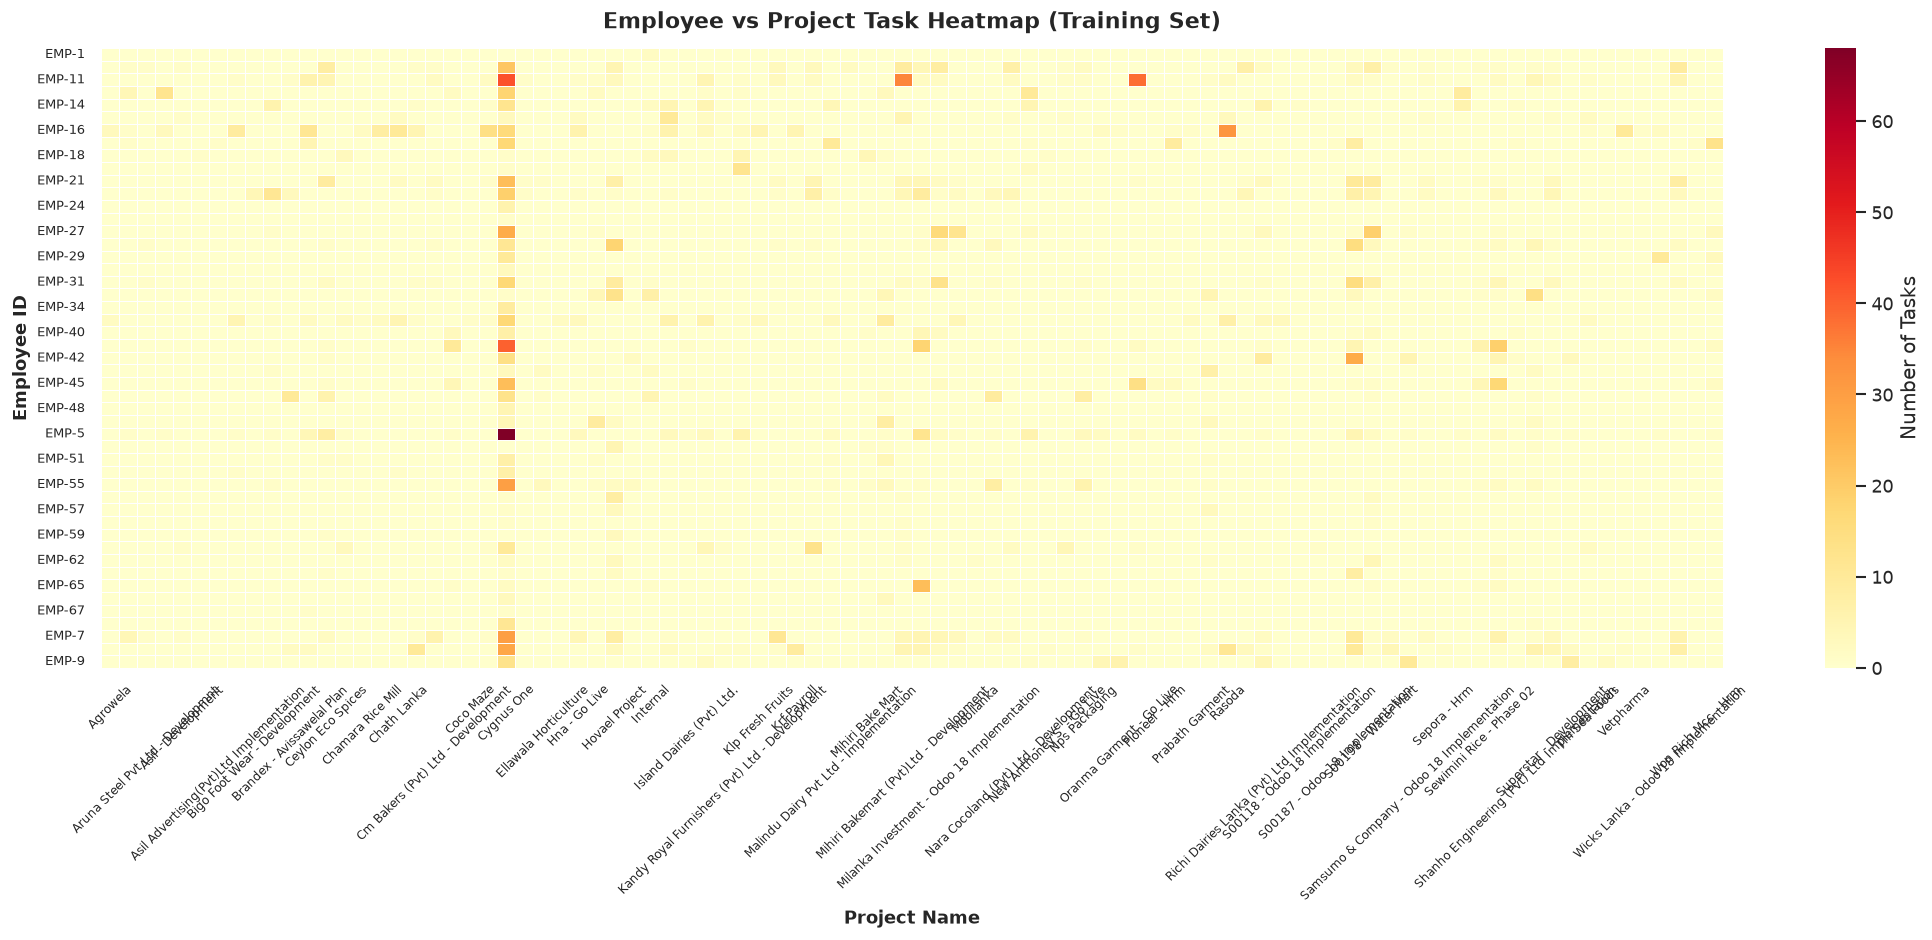

In [37]:
if "Project_Name" in train_agg.columns:
    emp_proj = (
        train_agg.groupby(["Employee_ID", "Project_Name"])["Task_ID"]
        .nunique()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(18, 8))
    sns.heatmap(
        emp_proj,
        cmap="YlOrRd",
        linewidths=0.4,
        linecolor="white",
        ax=ax,
        annot=(emp_proj.shape[1] <= 20),
        fmt="d",
        cbar_kws={"label": "Number of Tasks"}
    )
    ax.set_xlabel("Project Name", fontsize=11, fontweight="bold")
    ax.set_ylabel("Employee ID", fontsize=11, fontweight="bold")
    ax.set_title("Employee vs Project Task Heatmap (Training Set)", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Project_Name column not found")

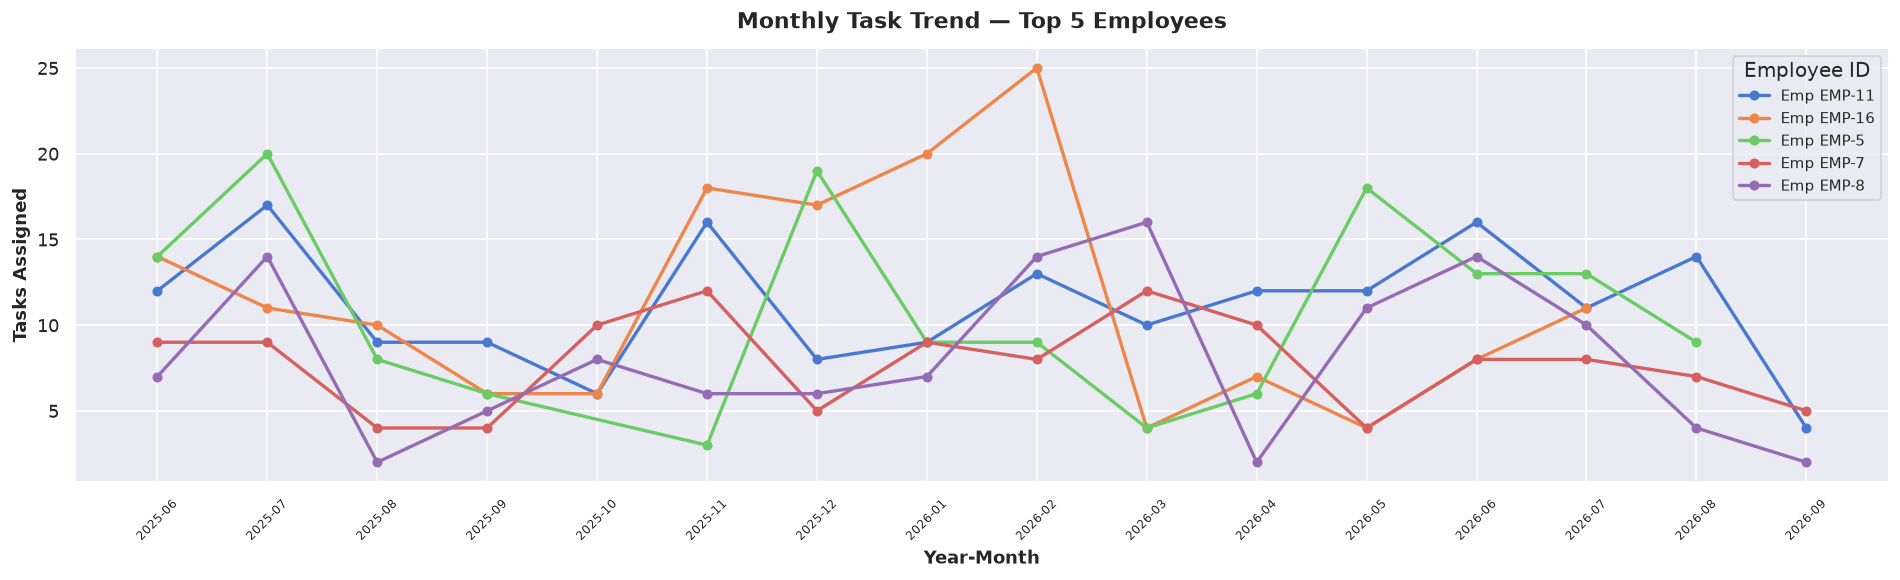

In [38]:
if "Created_Month" in train_agg.columns and "Created_Year" in train_agg.columns:
    train_agg["YearMonth"] = (
        train_agg["Created_Year"].astype(str) + "-" +
        train_agg["Created_Month"].astype(str).str.zfill(2)
    )

    monthly_emp = (
        train_agg.groupby(["YearMonth", "Employee_ID"])["Task_ID"]
        .nunique()
        .reset_index()
        .rename(columns={"Task_ID": "Task_Count"})
    )

    top5_emps = emp_task_counts.head(5)["Employee_ID"].tolist()
    monthly_top5 = monthly_emp[monthly_emp["Employee_ID"].isin(top5_emps)]

    fig, ax = plt.subplots(figsize=(16, 5))
    for emp_id, group in monthly_top5.groupby("Employee_ID"):
        group = group.sort_values("YearMonth")
        ax.plot(
            group["YearMonth"],
            group["Task_Count"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=f"Emp {emp_id}"
        )

    ax.set_xlabel("Year-Month", fontsize=11, fontweight="bold")
    ax.set_ylabel("Tasks Assigned", fontsize=11, fontweight="bold")
    ax.set_title("Monthly Task Trend — Top 5 Employees", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(title="Employee ID", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Created_Month or Created_Year column not found")

## Step 4: Build Train-Only Employee Historical Profiles

In [39]:
employee_profile = train_agg.groupby("Employee_ID").agg(
    historical_task_count=("Task_ID", "count"),
    historical_avg_planned_hours=("Estimated_Planned_Hours", "mean"),
    historical_avg_skill_count=("Task_Skill_Count", "mean"),
    historical_unique_projects=("Project_Name", "nunique"),
    historical_pct_medium=("Planned_Task_Size", lambda s: (s == "Medium").mean()),
    historical_pct_large=("Planned_Task_Size", lambda s: (s == "Large").mean()),
).reset_index()

emp_static = train_agg[["Employee_ID", "Employee_Department", "Employee_Job_Position"]].drop_duplicates()
employee_profile = employee_profile.merge(emp_static, on="Employee_ID", how="left")

employee_profile["log_historical_task_count"] = np.log1p(employee_profile["historical_task_count"])

os.makedirs("../data/processed/rank_datasets", exist_ok=True)
employee_profile.to_csv("../data/processed/rank_datasets/employee_profile_train.csv", index=False)

print(f"Employee profiles built: {employee_profile.shape}")
print(employee_profile[["Employee_ID", "historical_task_count", "log_historical_task_count"]].head(10))

Employee profiles built: (49, 10)
  Employee_ID  historical_task_count  log_historical_task_count
0       EMP-1                      2                   1.098612
1      EMP-10                    112                   4.727388
2      EMP-11                    178                   5.187386
3      EMP-12                     62                   4.143135
4      EMP-14                     55                   4.025352
5      EMP-15                     35                   3.583519
6      EMP-16                    161                   5.087596
7      EMP-17                     68                   4.234107
8      EMP-18                     21                   3.091042
9      EMP-20                     15                   2.772589


## Step 5: Define the Universe of Employees

In [40]:
TRAIN_EMPLOYEES = sorted(train_agg["Employee_ID"].unique())
N_EMPLOYEES = len(TRAIN_EMPLOYEES)
print(f"Candidate pool size: {N_EMPLOYEES}")

for name, df in [("val", val_agg), ("test", test_agg)]:
    missing = set(df["Employee_ID"].unique()) - set(TRAIN_EMPLOYEES)
    if missing:
        print(f"WARNING: {name} has {len(missing)} employees not in train pool: {missing}")
    else:
        print(f"{name}: all employees are within the train pool")

Candidate pool size: 49
val: all employees are within the train pool
test: all employees are within the train pool


## Step 6: Smart Negative Sampling

In [41]:
NEGATIVES_PER_TASK = 20
RANDOM_STATE = 42

def build_ranking_dataset(df, name, employee_pool, neg_per_task=NEGATIVES_PER_TASK):
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []

    task_to_positives = df.groupby("Task_ID")["Employee_ID"].apply(set).to_dict()

    task_features = df.drop_duplicates(subset=["Task_ID"]).drop(columns=["Employee_ID"])

    for task_id, pos_emps in task_to_positives.items():
        task_row = task_features[task_features["Task_ID"] == task_id].iloc[0].to_dict()
        neg_candidates = [e for e in employee_pool if e not in pos_emps]

        if len(neg_candidates) > neg_per_task:
            neg_emps = rng.choice(neg_candidates, size=neg_per_task, replace=False).tolist()
        else:
            neg_emps = neg_candidates

        for emp in pos_emps:
            row = {**task_row, "Employee_ID": emp, "relevance": 1}
            rows.append(row)

        for emp in neg_emps:
            row = {**task_row, "Employee_ID": emp, "relevance": 0}
            rows.append(row)

    out = pd.DataFrame(rows)
    print(f"{name}: {len(task_to_positives)} tasks -> {out.shape[0]} (task, employee) pairs")
    print(f"  Positive: {(out["relevance"] == 1).sum()}, Negative: {(out["relevance"] == 0).sum()}")
    return out

rank_train = build_ranking_dataset(train_agg, "train", TRAIN_EMPLOYEES)
rank_val   = build_ranking_dataset(val_agg, "val", TRAIN_EMPLOYEES)
rank_test  = build_ranking_dataset(test_agg, "test", TRAIN_EMPLOYEES)

train: 1709 tasks -> 36605 (task, employee) pairs
  Positive: 2425, Negative: 34180
val: 366 tasks -> 7829 (task, employee) pairs
  Positive: 509, Negative: 7320
test: 367 tasks -> 7827 (task, employee) pairs
  Positive: 487, Negative: 7340


## Step 7: Merge Employee Profile Features

In [42]:
EMPLOYEE_FEATURE_COLS = [
    "historical_task_count",
    "log_historical_task_count",
    "historical_avg_planned_hours",
    "historical_avg_skill_count",
    "historical_unique_projects",
    "historical_pct_medium",
    "historical_pct_large",
]

def merge_employee_profile(rank_df, profile, name):
    out = rank_df.merge(
        profile[["Employee_ID"] + EMPLOYEE_FEATURE_COLS],
        on="Employee_ID",
        how="left"
    )
    for col in EMPLOYEE_FEATURE_COLS:
        out[col] = out[col].fillna(profile[col].median())
    print(f"{name} after merge: {out.shape}")
    return out

rank_train = merge_employee_profile(rank_train, employee_profile, "train")
rank_val   = merge_employee_profile(rank_val,   employee_profile, "val")
rank_test  = merge_employee_profile(rank_test,  employee_profile, "test")

train after merge: (36605, 39)
val after merge: (7829, 38)
test after merge: (7827, 38)


## Step 8: Compute Sample Weights (Inverse Frequency)

In [43]:
def compute_sample_weights(rank_df, employee_pool):
    emp_freq = rank_df.groupby("Employee_ID").size()
    total = len(rank_df)
    inv_freq = total / (emp_freq * len(emp_freq))
    inv_freq = inv_freq.clip(lower=0.5, upper=5.0)

    pos_weight = 5.0

    weights = []
    for _, row in rank_df.iterrows():
        w = inv_freq.get(row["Employee_ID"], 1.0)
        if row["relevance"] == 1:
            w *= pos_weight
        weights.append(w)

    rank_df["sample_weight"] = weights
    return rank_df

rank_train = compute_sample_weights(rank_train, TRAIN_EMPLOYEES)
rank_val   = compute_sample_weights(rank_val,   TRAIN_EMPLOYEES)
rank_test  = compute_sample_weights(rank_test,  TRAIN_EMPLOYEES)

print(f"Train weight stats: min={rank_train["sample_weight"].min():.2f}, max={rank_train["sample_weight"].max():.2f}, mean={rank_train["sample_weight"].mean():.2f}")
print(f"Val weight stats:   min={rank_val["sample_weight"].min():.2f}, max={rank_val["sample_weight"].max():.2f}, mean={rank_val["sample_weight"].mean():.2f}")
print(f"Test weight stats:  min={rank_test["sample_weight"].min():.2f}, max={rank_test["sample_weight"].max():.2f}, mean={rank_test["sample_weight"].mean():.2f}")

Train weight stats: min=0.89, max=5.38, mean=1.26
Val weight stats:   min=0.89, max=6.05, mean=1.25
Test weight stats:  min=0.87, max=5.83, mean=1.24


## Step 9: Compute Group Sizes for XGBoost

In [44]:
def save_group_sizes(rank_df, name):
    group_sizes = rank_df.groupby("Task_ID", sort=False).size().tolist()
    path = f"../data/processed/rank_datasets/group_sizes_{name}.json"
    with open(path, "w") as f:
        json.dump(group_sizes, f)
    print(f"{name}: {len(group_sizes)} groups, mean size {np.mean(group_sizes):.1f}")
    return group_sizes

rank_train = rank_train.sort_values("Task_ID").reset_index(drop=True)
rank_val   = rank_val.sort_values("Task_ID").reset_index(drop=True)
rank_test  = rank_test.sort_values("Task_ID").reset_index(drop=True)

train_groups = save_group_sizes(rank_train, "train")
val_groups   = save_group_sizes(rank_val,   "val")
test_groups  = save_group_sizes(rank_test,  "test")

train: 1709 groups, mean size 21.4
val: 366 groups, mean size 21.4
test: 367 groups, mean size 21.3


### Task Distribution by Employee (Training Rank Dataset)

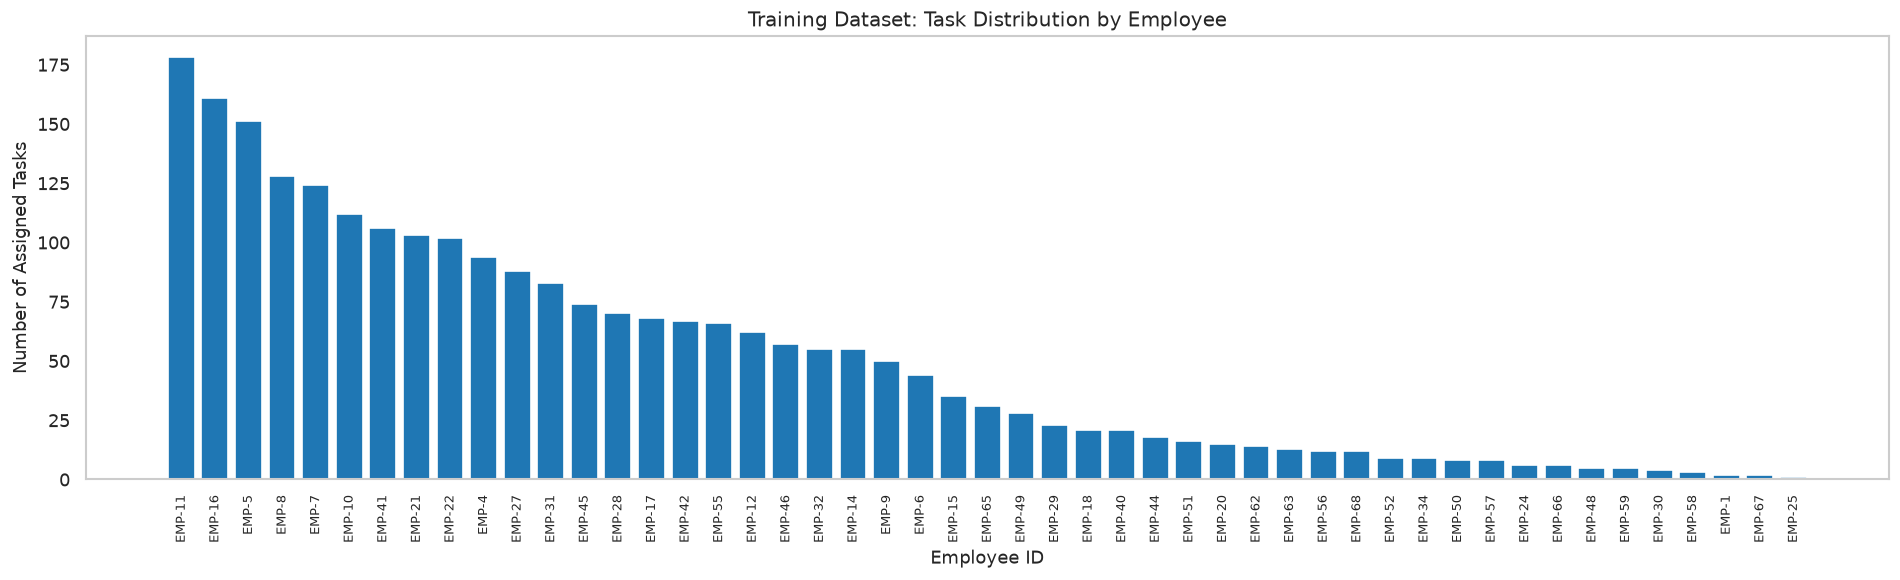

Total employees in rank_train: 49
Max tasks: 178 (EMP-11)
Min tasks: 1 (EMP-25)


In [45]:
emp_task_dist = (
    rank_train[rank_train["relevance"] == 1]
    .groupby("Employee_ID")["Task_ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Task_ID": "Task_Count"})
)

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(
    emp_task_dist["Employee_ID"].astype(str),
    emp_task_dist["Task_Count"],
    color="#1f77b4"
)

ax.set_xlabel("Employee ID", fontsize=11)
ax.set_ylabel("Number of Assigned Tasks", fontsize=11)
ax.set_title("Training Dataset: Task Distribution by Employee", fontsize=12)

ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

plt.tight_layout()
plt.show()

print(f"Total employees in rank_train: {emp_task_dist.shape[0]}")
print(f"Max tasks: {emp_task_dist['Task_Count'].max()} ({emp_task_dist.iloc[0]['Employee_ID']})")
print(f"Min tasks: {emp_task_dist['Task_Count'].min()} ({emp_task_dist.iloc[-1]['Employee_ID']})")

## Step 10: Encode Categorical Features

In [46]:
CATEGORICAL_TO_ENCODE = [
    "Project_Name",
    "Task_Priority",
    "Employee_Department",
    "Employee_Job_Position",
    "Planned_Task_Size",
]

encoders = {}
for col in CATEGORICAL_TO_ENCODE:
    if col not in rank_train.columns:
        print(f"Skipping {col}: not in DataFrame")
        continue
    le = LabelEncoder()
    all_values = pd.concat([
        rank_train[col], rank_val[col], rank_test[col]
    ]).astype(str)
    le.fit(all_values)
    for df in [rank_train, rank_val, rank_test]:
        df[col + "_enc"] = le.transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

os.makedirs("../data/processed/rank_datasets", exist_ok=True)
joblib.dump(encoders, "../data/processed/rank_datasets/label_encoders.pkl")
print("Label encoders saved.")

Encoded Project_Name: 91 unique values
Encoded Task_Priority: 2 unique values
Encoded Employee_Department: 8 unique values
Encoded Employee_Job_Position: 20 unique values
Encoded Planned_Task_Size: 3 unique values
Label encoders saved.


## Step 11: Define Feature Columns for Modeling

In [47]:
EXCLUDE_FROM_FEATURES = [
    "Task_ID", "Employee_ID", "relevance", "sample_weight",
    "Task_Name", "Task_Text", "Task_Description", "Project_Name",
    "Task_Priority", "Employee_Department", "Employee_Job_Position",
    "Planned_Task_Size", "Date", "Created_Date", "Deadline_Date",
]

FEATURE_COLS = [c for c in rank_train.columns if c not in EXCLUDE_FROM_FEATURES]
print(f"Number of features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Number of features: 30
['Estimated_Planned_Hours', 'Planned_Hours_Log', 'Task_Text_Length', 'Task_Word_Count', 'Task_Description_Length', 'Task_Name_Length', 'Has_Task_Description', 'Has_Deadline', 'Days_To_Deadline', 'Task_Skill_Count', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_Avg_Planned_Hours_Train', 'Created_Year', 'Created_Month', 'Created_DayOfWeek', 'Created_Quarter', 'YearMonth', 'historical_task_count', 'log_historical_task_count', 'historical_avg_planned_hours', 'historical_avg_skill_count', 'historical_unique_projects', 'historical_pct_medium', 'historical_pct_large', 'Project_Name_enc', 'Task_Priority_enc', 'Employee_Department_enc', 'Employee_Job_Position_enc', 'Planned_Task_Size_enc']


## Step 12: Save Final Datasets

In [48]:
output_dir = "../data/processed/rank_datasets"
os.makedirs(output_dir, exist_ok=True)

rank_train.to_csv(f"{output_dir}/rank_train.csv", index=False)
rank_val.to_csv(f"{output_dir}/rank_val.csv",   index=False)
rank_test.to_csv(f"{output_dir}/rank_test.csv",  index=False)

metadata = {
    "n_train_tasks": int(rank_train["Task_ID"].nunique()),
    "n_val_tasks": int(rank_val["Task_ID"].nunique()),
    "n_test_tasks": int(rank_test["Task_ID"].nunique()),
    "n_employees": N_EMPLOYEES,
    "negatives_per_task": NEGATIVES_PER_TASK,
    "feature_cols": FEATURE_COLS,
    "employee_feature_cols": EMPLOYEE_FEATURE_COLS,
    "max_min_imbalance_ratio": float(
        employee_profile["historical_task_count"].max() /
        employee_profile["historical_task_count"].min()
    ),
    "leakage_columns_dropped": LEAKAGE_COLS,
    "formulation": "learning_to_rank",
    "imbalance_handling": "rank_objective + inverse_freq_weights + smart_negative_sampling",
}

with open(f"{output_dir}/dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Datasets saved.")
print(f"Train: {rank_train.shape}, Val: {rank_val.shape}, Test: {rank_test.shape}")

Datasets saved.
Train: (36605, 45), Val: (7829, 44), Test: (7827, 44)


## Step 13: Validation Checks

In [49]:
assert set(rank_train["Task_ID"]).isdisjoint(set(rank_val["Task_ID"]))
assert set(rank_train["Task_ID"]).isdisjoint(set(rank_test["Task_ID"]))
print("No Task_ID leakage")

for name, df in [("train", rank_train), ("val", rank_val), ("test", rank_test)]:
    pos_per_task = df[df["relevance"] == 1].groupby("Task_ID").size()
    assert (pos_per_task >= 1).all(), f"{name} has tasks with no positives"
print("Every task has at least one positive")

val_emps  = set(rank_val["Employee_ID"].unique())
test_emps = set(rank_test["Employee_ID"].unique())
print(f"Val employees:  {len(val_emps)}/{N_EMPLOYEES}")
print(f"Test employees: {len(test_emps)}/{N_EMPLOYEES}")

for name, df in [("train", rank_train), ("val", rank_val), ("test", rank_test)]:
    pos_rate = df["relevance"].mean()
    print(f"{name} positive rate: {pos_rate:.3f}")

for name, df in [("train", rank_train), ("val", rank_val), ("test", rank_test)]:
    expected_groups = df["Task_ID"].nunique()
    total_pairs = len(df)
    print(f"{name}: {expected_groups} tasks, total (task, employee) pairs = {total_pairs}")

print("All validation checks passed")

No Task_ID leakage
Every task has at least one positive
Val employees:  49/49
Test employees: 49/49
train positive rate: 0.066
val positive rate: 0.065
test positive rate: 0.062
train: 1709 tasks, total (task, employee) pairs = 36605
val: 366 tasks, total (task, employee) pairs = 7829
test: 367 tasks, total (task, employee) pairs = 7827
All validation checks passed
